In [1]:
import sys
import os
import pickle
import logging
import numba
import matplotlib
import matplotlib.pyplot as plt
logging.getLogger('matplotlib.font_manager').disabled = True
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)

matplotlib_logger = logging.getLogger('matplotlib')
matplotlib_logger.setLevel(logging.WARNING)

# Add the src directory to sys.path
src_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(src_path)

from src.IndependentSteps import Pycromanager2NativeDataType, FFF2NativeDataType, Make_Output_Dir_JF, Make_Analysis_Dir_JF, \
                                    ConsolidateImageShapes, TrimZSlices, AutomaticSpotDetection_JF

from src.SequentialSteps import CellSegmentationStepClass_JF, BIGFISH_SpotDetection, SimpleCellposeSegmentaion, IlluminationCorrection, IlluminationCorrection_BGFG

from src.FinalizationSteps import Save_Outputs, Save_Images, Save_Parameters, Save_Masks, return_to_NAS, remove_local_data_but_keep_h5

from src.Parameters import Parameters, Experiment, Settings, ScopeClass, DataContainer

from src.GeneralOutput import OutputClass

from src.Displays import Display

from src.GUI import GUI, StepGUI

from src.Pipeline import Pipeline

INFO:numexpr.utils:NumExpr defaulting to 8 threads.
DEBUG:h5py._conv:Creating converter from 7 to 5
DEBUG:h5py._conv:Creating converter from 5 to 7
DEBUG:h5py._conv:Creating converter from 7 to 5
DEBUG:h5py._conv:Creating converter from 5 to 7


In [2]:
# # List of directories to process
# initial_data_location=(
#         'smFISH_images/Eric_smFISH_images/20220718/DUSP1_conc_sweep_R2_0min_071422' ,   
#         'smFISH_images/Eric_smFISH_images/20220718/DUSP1_conc_sweep_R2_1nM_75min_071422' ,    
#         'smFISH_images/Eric_smFISH_images/20220718/DUSP1_conc_sweep_R2_10nM_75min_071422' )
# # Parameters
# Condition = 'DUSP1_timesweep'      # Experimental condition. The options are:  'GR_timesweep' , 'DUSP1_timesweep' 
# Replica = 'H'                   # Replica name. 
# time_list  = [0, 75, 75]        # Time of image acquisition
# DexConc_list = [0, 1, 10]        # Dex concentration

# # Creating the list of dictionaries
# DUSP1_CS_R2 = [
#     {
#         "condition": Condition,
#         "replica": Replica,
#         "time": time,
#         "Dex_Conc": DexConc
#     }
#     for time, DexConc in zip(time_list, DexConc_list)
# ]
# # Output the result
# print(DUSP1_CS_R2)

In [3]:
initial_data_location=(
        'smFISH_images/Eric_smFISH_images/20230511/GR_ICC_3hr_R1_1nM_0min_050823',
        'smFISH_images/Eric_smFISH_images/20230516/GR_ICC_3hr_R1_10nM_0min_050823' ,
        'smFISH_images/Eric_smFISH_images/20230522/GR_ICC_3hr_R1_100nM_0min_050823' ,
)
# Parameters
Condition = 'GR_timesweep'      # Experimental condition. The options are:  'GR_timesweep' , 'DUSP1_timesweep' 
Replica = 'A'                   # Replica name. 
time_list  = [0, 0, 0]        # Time of image acquisition
DexConc_list = [0, 0, 0]        # Dex concentration


# Creating the list of dictionaries
GR_ICC_R1 = [
    {
        "condition": Condition,
        "replica": Replica,
        "time": time,
        "Dex_Conc": DexConc
    }
    for time, DexConc in zip(time_list, DexConc_list)
]

# Ensuring the length matches the number of directories
assert len(GR_ICC_R1) == len(initial_data_location), "Mismatch between number of directories and experimental parameters."

# Output the result
print(GR_ICC_R1)

[{'condition': 'GR_timesweep', 'replica': 'A', 'time': 0, 'Dex_Conc': 0}, {'condition': 'GR_timesweep', 'replica': 'A', 'time': 0, 'Dex_Conc': 0}, {'condition': 'GR_timesweep', 'replica': 'A', 'time': 0, 'Dex_Conc': 0}]


In [4]:
# Initialize Parameters
scope = ScopeClass()
scope.voxel_size_yx = 160
scope.spot_yx = 300
scope.spot_z = 500 
data = DataContainer()
settings = Settings(name='ER_Dec0324', )
settings.display_plots = True 
experiment = Experiment()
experiment.independent_params = GR_ICC_R1
experiment.initial_data_location = initial_data_location
experiment.snr_threshold = 4

experiment.sigma_dict = {0: 150, 1: 100}

settings.load_in_mask = False
experiment.FISHChannel = 0
experiment.nucChannel = 1
experiment.cytoChannel = 1
experiment.voxel_size_z = 500

settings.cellpose_min_size = 100
settings.cellpose_diameter = [180, 90] # most of these options can be done for individually cyto and nuc segmentation, 
                                        # and a list can be or a single float can be passed for both
                                        # always in the order cyto, nuc
settings.cellpose_pretrained_model = ["GAPDH_cyto", 'DAPI_nuclei'] 

In [5]:
# You can check that all the manditory parameters are set by calling validate
Parameters.validate()

None


In [6]:
FFF2NativeDataType()
IlluminationCorrection_BGFG()
# SimpleCellposeSegmentaion()
# BIGFISH_SpotDetection()
# Save_Masks()
# Save_Parameters()
# Save_Outputs()

In [7]:
pipeline = Pipeline()

In [8]:
Parameters.get_parameters()

{'voxel_size_yx': 160,
 'spot_z': 500,
 'spot_yx': 300,
 'microscope_saving_format': 'pycromanager',
 'local_dataset_location': None,
 'h5_file': None,
 'total_num_chunks': None,
 'images': None,
 'masks': None,
 'name': 'ER_Dec0324',
 'return_data_to_NAS': True,
 'NUMBER_OF_CORES': 4,
 'save_files': True,
 'num_chunks_to_run': 100000,
 'download_data_from_NAS': True,
 'connection_config_location': '/Users/ericron/Desktop/uqbio24/FISH_Processing/config_nas.yml',
 'share_name': 'share',
 'display_plots': True,
 'load_in_mask': False,
 'cellpose_min_size': 100,
 'cellpose_diameter': [180, 90],
 'cellpose_pretrained_model': ['GAPDH_cyto', 'DAPI_nuclei'],
 'initial_data_location': ('smFISH_images/Eric_smFISH_images/20230511/GR_ICC_3hr_R1_1nM_0min_050823',
  'smFISH_images/Eric_smFISH_images/20230516/GR_ICC_3hr_R1_10nM_0min_050823',
  'smFISH_images/Eric_smFISH_images/20230522/GR_ICC_3hr_R1_100nM_0min_050823'),
 'index_dict': None,
 'nucChannel': 1,
 'cytoChannel': 1,
 'FISHChannel': [0],
 

Overwriting voxel_size_yx in ScopeClass
Overwriting spot_z in ScopeClass
Overwriting spot_yx in ScopeClass
Overwriting microscope_saving_format in ScopeClass
Overwriting local_dataset_location in DataContainer
Overwriting h5_file in DataContainer
Overwriting total_num_chunks in DataContainer
Overwriting images in DataContainer
Overwriting masks in DataContainer
Overwriting name in Settings
Overwriting return_data_to_NAS in Settings
Overwriting NUMBER_OF_CORES in Settings
Overwriting save_files in Settings
Overwriting num_chunks_to_run in Settings
Overwriting download_data_from_NAS in Settings
Overwriting connection_config_location in Settings
Overwriting share_name in Settings
Overwriting display_plots in Settings
Overwriting load_in_mask in Settings
Overwriting cellpose_min_size in Settings
Overwriting cellpose_diameter in Settings
Overwriting cellpose_pretrained_model in Settings
Overwriting initial_data_location in Experiment
Overwriting index_dict in Experiment
Overwriting nucChann

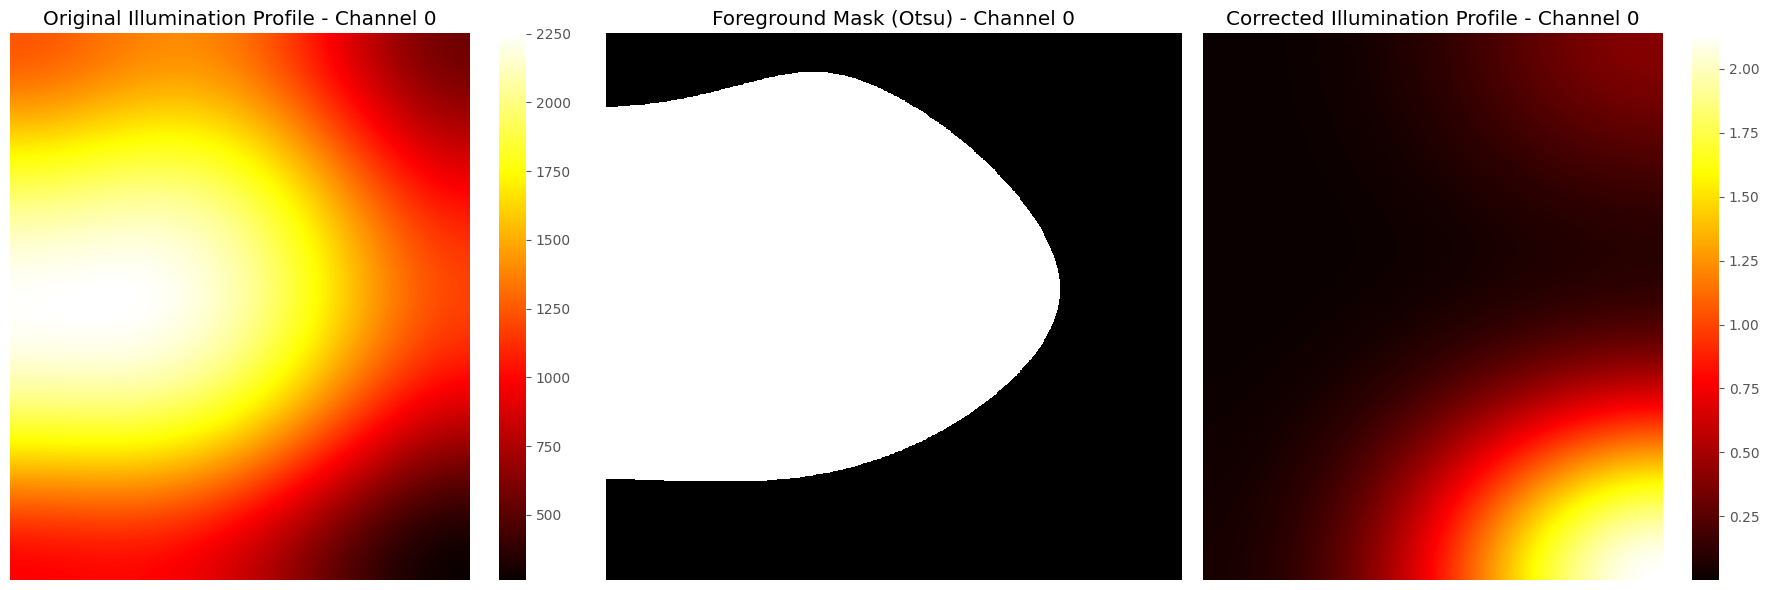

Visualizing channel 1...


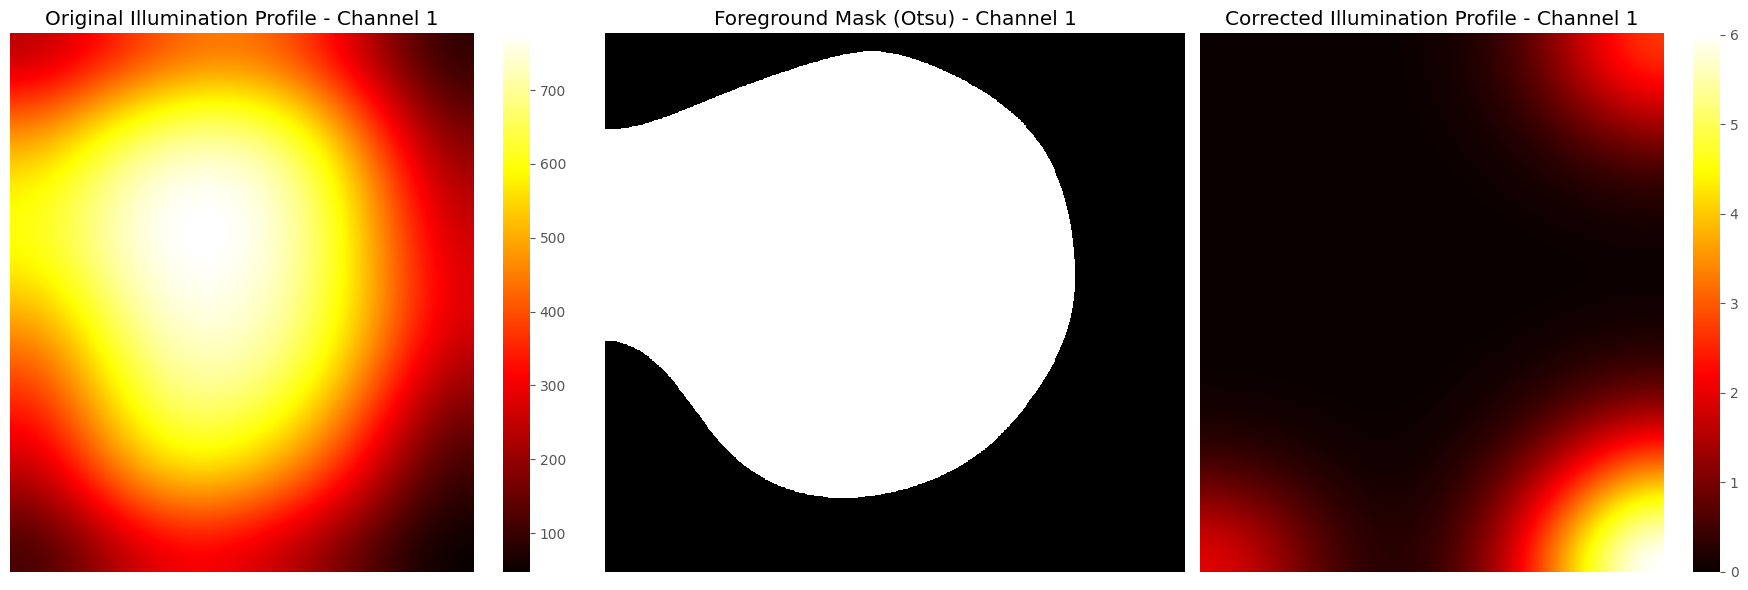

Visualization complete.
Illumination correction pipeline complete.
Overwriting images in DataContainer
Adding leftover kwargs to Settings
Adding illumination_profiles to Settings
Running Sequential Steps
++++++++++++++++++++++++++++
Running :  SequentialStepsClass
++++++++++++++++++++++++++++

 ###################### 
FOV:0 TIMEPOINT : 0
 ###################### 
++++++++++++++++++++++++++++
Running :  SequentialStepsClass
++++++++++++++++++++++++++++

 ###################### 
FOV:1 TIMEPOINT : 0
 ###################### 
++++++++++++++++++++++++++++
Running :  SequentialStepsClass
++++++++++++++++++++++++++++

 ###################### 
FOV:2 TIMEPOINT : 0
 ###################### 
++++++++++++++++++++++++++++
Running :  SequentialStepsClass
++++++++++++++++++++++++++++

 ###################### 
FOV:3 TIMEPOINT : 0
 ###################### 
++++++++++++++++++++++++++++
Running :  SequentialStepsClass
++++++++++++++++++++++++++++

 ###################### 
FOV:4 TIMEPOINT : 0
 ###############

TypeError: Can't instantiate abstract class FinalizingStepClass with abstract method main

In [9]:
pipeline.run()